# Pivot Tables :-

In [1]:
#lets see what it add in our inventory 

In [2]:
import numpy as np 
import pandas as pd 
import seaborn as sns 


#loading the titanic data to perform the function on the data and learn the concept 
titanic = sns.load_dataset('titanic')#it is data of the titanic which is like data for about something 
titanic


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [3]:
#survival rate on  the basis of the sex 
titanic.groupby('sex')['survived'].mean()

sex
female    0.742038
male      0.188908
Name: survived, dtype: float64

In [4]:
#digging more in the data by finding the survival rate on the basis of the both class and the sex 
titanic.groupby(['class','sex'])['survived'].aggregate('mean').unstack()

C:\Users\Monu Verma\AppData\Local\Temp\ipykernel_22692\2828715795.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  titanic.groupby(['class','sex'])['survived'].aggregate('mean').unstack()


sex,female,male
class,,
First,0.968085,0.368852
Second,0.921053,0.157407
Third,0.500000,0.135447


In [5]:
#here we observed that first class survival rate of female is good only 1 is dying in 20 and in men it is 1 is surviving in 3 
#here the worst for both women and men becomes at the third class where women surving rate decrease to the 50 percent and for men it decirease 26 percent 

In [6]:
#pivot table 
titanic.pivot_table('survived' , index = 'sex' , columns = 'class' , aggfunc = 'mean')

C:\Users\Monu Verma\AppData\Local\Temp\ipykernel_22692\3017234222.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  titanic.pivot_table('survived' , index = 'sex' , columns = 'class' , aggfunc = 'mean')


class,First,Second,Third
sex,,,
female,0.968085,0.921053,0.500000
male,0.368852,0.157407,0.135447


In [7]:
#Multilevel pivot table 

In [18]:
age = pd.cut(titanic['age'],[0,18,80]
            )#pd.cut basically create the bins of the contiusly continuing data 

In [21]:
titanic.pivot_table('survived',['sex',age] , 'class')#basically here we did not specifed columns and rows but basically we just writed we have to assume that first one is going to be the indexx and second one is going to be the columns 

C:\Users\Monu Verma\AppData\Local\Temp\ipykernel_22692\214388797.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  titanic.pivot_table('survived',['sex',age] , 'class')#basically here we did not specifed columns and rows but basically we just writed we have to assume that first one is going to be the indexx and second one is going to be the columns


class               First    Second     Third
sex    age                                   
female (0, 18]   0.909091  1.000000  0.511628
       (18, 80]  0.972973  0.900000  0.423729
male   (0, 18]   0.800000  0.600000  0.215686
       (18, 80]  0.375000  0.071429  0.133663

In [23]:
#multiple columns in the pivot
fare = pd.qcut(titanic['fare'], 2)

In [24]:
fare

0       (-0.001, 14.454]
1      (14.454, 512.329]
2       (-0.001, 14.454]
3      (14.454, 512.329]
4       (-0.001, 14.454]
             ...        
886     (-0.001, 14.454]
887    (14.454, 512.329]
888    (14.454, 512.329]
889    (14.454, 512.329]
890     (-0.001, 14.454]
Name: fare, Length: 891, dtype: category
Categories (2, interval[float64, right]): [(-0.001, 14.454] < (14.454, 512.329]]

In [25]:
#pivoting multiple columns and index 
titanic.pivot_table('survived',['sex',age],['class',fare])

C:\Users\Monu Verma\AppData\Local\Temp\ipykernel_22692\3017065632.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  titanic.pivot_table('survived',['sex',age],['class',fare])


class                      First                             Second  \
fare            (-0.001, 14.454] (14.454, 512.329] (-0.001, 14.454]   
sex    age                                                            
female (0, 18]               NaN          0.909091         1.000000   
       (18, 80]              NaN          0.972973         0.880000   
male   (0, 18]               NaN          0.800000         0.000000   
       (18, 80]              0.0          0.391304         0.098039   

class                                        Third                    
fare            (14.454, 512.329] (-0.001, 14.454] (14.454, 512.329]  
sex    age                                                            
female (0, 18]           1.000000         0.714286          0.318182  
       (18, 80]          0.914286         0.444444          0.391304  
male   (0, 18]           0.818182         0.260870          0.178571  
       (18, 80]          0.030303         0.125000          0.192308

In [28]:
# #the full potential of the pivot table is like this 
# DataFrame.pivot_table(data,value=None, index = None , columns = None , afffunc = 'mean' ,
#                       fillna = None , dropna = None, margins = False , observed = False , 
#                       # margins_all = False , Sort = True)

In [32]:
#we can know that aggregation by default is a mean but we can specify it 
titanic.pivot_table(index = 'sex' , columns = 'class' , aggfunc = {'survived':sum , 'fare':'mean'})#this is different because due to the aggfunc  function we didn't have specifed values dictionary 

C:\Users\Monu Verma\AppData\Local\Temp\ipykernel_22692\3951032634.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  titanic.pivot_table(index = 'sex' , columns = 'class' , aggfunc = {'survived':sum , 'fare':'mean'})#this is different because due to the aggfunc  function we didn't have specifed values dictionary
C:\Users\Monu Verma\AppData\Local\Temp\ipykernel_22692\3951032634.py:2: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  titanic.pivot_table(index = 'sex' , columns = 'class' , aggfunc = {'survived':sum , 'fare':'mean'})#this is different because due to the aggfunc  function we didn't have specifed values dictionary


fare                       survived             
class        First     Second      Third    First Second Third
sex                                                           
female  106.125798  21.970121  16.118810       91     70    72
male     67.226127  19.741782  12.661633       45     17    47

# Pivot Table Example - Birth Rate Data

In [33]:
birth_rate = pd.read_csv('births.csv')

In [34]:
birth_rate

,year,month,day,gender,births
0,1969,1,1.0,F,4046
1,1969,1,1.0,M,4440
2,1969,1,2.0,F,4454
3,1969,1,2.0,M,4548
4,1969,1,3.0,F,4548
...,...,...,...,...,...
15542,2008,10,NaN,M,183219
15543,2008,11,NaN,F,158939
15544,2008,11,NaN,M,165468
15545,2008,12,NaN,F,173215


In [36]:
birth_rate.describe()

,year,month,day,births
count,15547.000000,15547.000000,15067.000000,15547.000000
mean,1979.037435,6.515919,17.769894,9762.293561
std,6.728340,3.449632,15.284034,28552.465810
min,1969.000000,1.000000,1.000000,1.000000
25%,1974.000000,4.000000,8.000000,4358.000000
50%,1979.000000,7.000000,16.000000,4814.000000
75%,1984.000000,10.000000,24.000000,5289.500000
max,2008.000000,12.000000,99.000000,199622.000000


In [37]:
birth_rate.head()

,year,month,day,gender,births
0,1969,1,1.0,F,4046
1,1969,1,1.0,M,4440
2,1969,1,2.0,F,4454
3,1969,1,2.0,M,4548
4,1969,1,3.0,F,4548


In [39]:
birth_rate.tail()

,year,month,day,gender,births
15542,2008,10,NaN,M,183219
15543,2008,11,NaN,F,158939
15544,2008,11,NaN,M,165468
15545,2008,12,NaN,F,173215
15546,2008,12,NaN,M,181235


In [46]:
birth_rate['decade'] = 10*(birth_rate['year']//10)#code for adding a decade mean like 10 year gap 
birth_rate.pivot_table('births' , index = 'decade' , columns = 'gender',aggfunc = 'sum')

gender,F,M
decade,,
1960,1753634,1846572
1970,16263075,17121550
1980,18310351,19243452
1990,19479454,20420553
2000,18229309,19106428


In [47]:
#male birth rate outnumbe female birth rate at all the time 

Text(0, 0.5, 'Total birth per year')

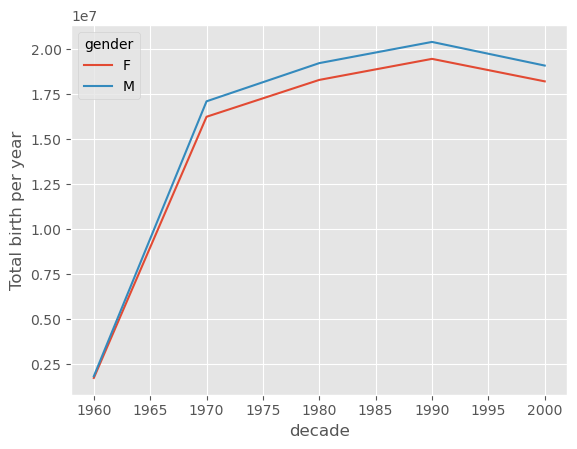

In [52]:
%matplotlib inline 
import matplotlib.pyplot as plt 

plt.style.use('ggplot')
birth_rate.pivot_table('births' , index = 'decade' , columns = 'gender',aggfunc = 'sum').plot()

plt.grid(True)
plt.ylabel('Total birth per year')